# Notebook 19 — Case Study Diagnostic: Philippines & Iraq

**Purpose:** Contrast two forms of neo-colonial violence against journalists:
- **Philippines (PHL)** — US colonial tie active, ODA×colonial channel partially captured by model, Duterte period anchor
- **Iraq (IRQ)** — US colonial_tie=0, military invasion mechanism invisible to model

Same patron (US), two completely different mechanisms. The contrast shows which forms of US power are legible to the model and which aren't.

**Outputs:** `../outputs/case_study/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
import os
import shutil

warnings.filterwarnings('ignore')
os.makedirs('../../outputs/case_study', exist_ok=True)
os.makedirs('../../outputs/final_report/06_case_study', exist_ok=True)

RED   = '#BF3A27'
GOLD  = '#C7922A'
DARK  = '#323232'
LIGHT = '#F5F0E8'
GRAY  = '#888780'
BLUE  = '#2C5F8A'

PHL_COLOR = BLUE
IRQ_COLOR = RED

print('Ready.')

Ready.


## 1. Load Data

In [2]:
panel = pd.read_csv('../../data/merged/panel_final_1992_2024.csv')
print(f'Panel: {panel.shape}')
print(list(panel.columns))

Panel: (6358, 38)
['recipient_iso3', 'year', 'arms_tiv_total', 'oda_total', 'econ_neocol_score_total', 'colonial_tie_flag', 'journalist_killings', 'gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity', 'arms_tiv_in_strength_lag1', 'arms_tiv_out_strength_lag1', 'arms_tiv_dependency_balance_lag1', 'arms_tiv_in_concentration_lag1', 'arms_tiv_pagerank_lag1', 'bilateral_oda_in_strength_lag1', 'bilateral_oda_out_strength_lag1', 'bilateral_oda_dependency_balance_lag1', 'bilateral_oda_in_concentration_lag1', 'bilateral_oda_pagerank_lag1', 'colonial_tie_in_strength_lag1', 'colonial_tie_out_strength_lag1', 'colonial_tie_dependency_balance_lag1', 'colonial_tie_in_concentration_lag1', 'colonial_tie_pagerank_lag1', 'econ_neocol_score_in_strength_lag1', 'econ_neocol_score_out_strength_lag1', 'econ_neocol_score_dependency_balance_lag1', 'econ_neocol_score_in_concentration_lag1', 'econ_neocol_score_pagerank_lag1', 'arms_tiv_total_log', 'oda_tota

In [3]:
dyadic = pd.read_csv('../../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv')
print(f'Dyadic: {dyadic.shape}')
print(list(dyadic.columns))

Dyadic: (115640, 15)
['sender_iso3', 'recipient_iso3', 'year', 'arms_tiv', 'bilateral_oda', 'econ_neocol_score', 'colonial_tie', 'journalist_killings', 'gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity', 'econ_neocol_score_log']


In [4]:
# Detect correct column names defensively
if 'colonial_tie_flag' in panel.columns:
    TIE_COL = 'colonial_tie_flag'
elif 'colonial_tie' in panel.columns:
    TIE_COL = 'colonial_tie'
else:
    raise ValueError('No colonial tie column. Available: ' + str(list(panel.columns)))

ODA_COL  = next((c for c in ['oda_total_log_lag1','bilateral_oda_log_lag1']
                 if c in panel.columns),
                next((c for c in panel.columns if 'oda' in c.lower() and 'lag' in c.lower()), None))

ARMS_COL = next((c for c in ['arms_tiv_total_log_lag1']
                 if c in panel.columns),
                next((c for c in panel.columns if 'arms' in c.lower() and 'lag' in c.lower()), None))

ECON_COL = next((c for c in ['econ_neocol_score_total_lag1']
                 if c in panel.columns),
                next((c for c in panel.columns if 'econ' in c.lower() and 'lag' in c.lower()), None))

print(f'TIE : {TIE_COL}')
print(f'ODA : {ODA_COL}')
print(f'ARMS: {ARMS_COL}')
print(f'ECON: {ECON_COL}')

TIE : colonial_tie_flag
ODA : oda_total_log_lag1
ARMS: arms_tiv_total_log_lag1
ECON: econ_neocol_score_total_lag1


## 2. Re-fit Baseline Hurdle Model

In [5]:
BASELINE = [c for c in [ARMS_COL, ODA_COL, ECON_COL, TIE_COL,
                         'gdp_per_capita_log', 'population_log',
                         'armed_conflict', 'conflict_intensity'] if c]

panel['oda_x_colonial']  = panel[ODA_COL]  * panel[TIE_COL]
panel['econ_x_colonial'] = panel[ECON_COL] * panel[TIE_COL]
panel['arms_x_colonial'] = panel[ARMS_COL] * panel[TIE_COL]

FEATURES = BASELINE + ['oda_x_colonial', 'econ_x_colonial', 'arms_x_colonial']

model_df = panel.dropna(subset=FEATURES + ['journalist_killings']).copy()
print(f'Rows: {len(model_df)} | Countries: {model_df["recipient_iso3"].nunique()}')
print(f'Zero share: {(model_df["journalist_killings"]==0).mean():.1%}')

Rows: 5765 | Countries: 196
Zero share: 88.1%


In [6]:
model_df['any_killing'] = (model_df['journalist_killings'] > 0).astype(int)
X_logit = sm.add_constant(model_df[FEATURES])

logit_model = sm.Logit(model_df['any_killing'], X_logit).fit(
    cov_type='cluster',
    cov_kwds={'groups': model_df['recipient_iso3']},
    maxiter=200, disp=False
)
print('Logit fitted.')
print(logit_model.summary2().tables[1][['Coef.','Std.Err.','P>|z|']].round(3))

Logit fitted.
                               Coef.  Std.Err.  P>|z|
const                        -13.949     1.804  0.000
arms_tiv_total_log_lag1       -0.148     0.069  0.032
oda_total_log_lag1             0.096     0.079  0.226
econ_neocol_score_total_lag1   0.057     0.065  0.385
colonial_tie_flag             -0.133     0.516  0.796
gdp_per_capita_log             0.227     0.096  0.018
population_log                 0.553     0.081  0.000
armed_conflict                -0.582     0.474  0.219
conflict_intensity             1.606     0.330  0.000
oda_x_colonial                 0.172     0.092  0.060
econ_x_colonial               -0.115     0.078  0.141
arms_x_colonial                0.096     0.081  0.234


In [7]:
nonzero_df = model_df[model_df['journalist_killings'] > 0].copy()
X_negbin   = sm.add_constant(nonzero_df[FEATURES])

negbin_model = sm.NegativeBinomial(
    nonzero_df['journalist_killings'], X_negbin
).fit(
    cov_type='cluster',
    cov_kwds={'groups': nonzero_df['recipient_iso3']},
    maxiter=200, disp=False
)
print('NegBin fitted.')
print(negbin_model.summary2().tables[1][['Coef.','Std.Err.','P>|z|']].round(3))

NegBin fitted.
                              Coef.  Std.Err.  P>|z|
const                        -1.955     1.352  0.148
arms_tiv_total_log_lag1      -0.047     0.054  0.383
oda_total_log_lag1            0.008     0.046  0.859
econ_neocol_score_total_lag1 -0.087     0.043  0.044
colonial_tie_flag            -0.785     0.316  0.013
gdp_per_capita_log            0.219     0.074  0.003
population_log                0.061     0.061  0.317
armed_conflict               -1.002     0.383  0.009
conflict_intensity            1.221     0.224  0.000
oda_x_colonial                0.139     0.056  0.013
econ_x_colonial               0.070     0.052  0.181
arms_x_colonial               0.017     0.054  0.750
alpha                         0.438     0.063  0.000


## 3. Generate Predictions

In [8]:
X_all = sm.add_constant(model_df[FEATURES], has_constant='add')

model_df['p_any_killing']      = logit_model.predict(X_all)
model_df['pred_count_nonzero'] = negbin_model.predict(X_all)
model_df['pred_count_hurdle']  = model_df['p_any_killing'] * model_df['pred_count_nonzero']
model_df['residual']           = model_df['journalist_killings'] - model_df['pred_count_hurdle']

print('Predictions done.')
print(model_df[['recipient_iso3','year','journalist_killings',
                'p_any_killing','pred_count_hurdle','residual']].head(6))

Predictions done.
  recipient_iso3  year  journalist_killings  p_any_killing  pred_count_hurdle  \
1            ABW  1993                    0       0.005260           0.012405   
2            ABW  1994                    0       0.005389           0.012971   
3            ABW  1995                    0       0.005331           0.012902   
4            ABW  1996                    0       0.005513           0.013401   
5            ABW  1997                    0       0.005780           0.014300   
6            ABW  1998                    0       0.006021           0.015132   

   residual  
1 -0.012405  
2 -0.012971  
3 -0.012902  
4 -0.013401  
5 -0.014300  
6 -0.015132  


## 4. Country Summary

In [9]:
country_summary = model_df.groupby('recipient_iso3').agg(
    total_killings = ('journalist_killings', 'sum'),
    mean_killings  = ('journalist_killings', 'mean'),
    total_pred     = ('pred_count_hurdle',   'sum'),
    mean_pred      = ('pred_count_hurdle',   'mean'),
    mean_residual  = ('residual',            'mean'),
    mean_p_any     = ('p_any_killing',       'mean'),
    colonial_tie   = (TIE_COL,               'max'),
    n_years        = ('year',                'count')
).reset_index().sort_values('total_killings', ascending=False)

country_summary.to_csv('../../outputs/case_study/country_residuals.csv', index=False)
print('Top 15:')
print(country_summary.head(15)[[
    'recipient_iso3','total_killings','total_pred','mean_residual','colonial_tie'
]].to_string())

Top 15:
    recipient_iso3  total_killings  total_pred  mean_residual  colonial_tie
82             IRQ             285  128.328197       4.895994             1
83             ISR             181   20.528702       5.014728             1
111            MEX             158   30.783974       3.975501             1
167            SYR             155   84.673623       2.344213             1
138            PHL             155   57.128114       3.058496             1
135            PAK             104   96.846438       0.223549             1
38             COL              96   90.521748       0.171195             1
79             IND              89  100.412003      -0.356625             1
157            SOM              86   92.570944      -0.205342             1
1              AFG              77   34.049201       1.789617             0
24             BRA              60   33.282740       0.834914             1
50             DZA              59   44.189555       0.462826             1
74  

In [10]:
print('\nSpotlight:')
for iso in ['PHL','IRQ','CMR','SYR','MEX','PAK']:
    r = country_summary[country_summary['recipient_iso3']==iso]
    if not len(r):
        print(f'{iso}: not found'); continue
    r = r.iloc[0]
    df_iso = model_df[model_df['recipient_iso3']==iso]
    peak = df_iso.loc[df_iso['journalist_killings'].idxmax(),'year']
    print(f"{iso}: killings={r['total_killings']:.0f} | pred={r['total_pred']:.1f} | "
          f"residual={r['mean_residual']:.2f} | colonial_tie={r['colonial_tie']:.0f} | peak={peak}")


Spotlight:
PHL: killings=155 | pred=57.1 | residual=3.06 | colonial_tie=1 | peak=2009
IRQ: killings=285 | pred=128.3 | residual=4.90 | colonial_tie=1 | peak=2006
CMR: killings=4 | pred=13.0 | residual=-0.28 | colonial_tie=1 | peak=2023
SYR: killings=155 | pred=84.7 | residual=2.34 | colonial_tie=1 | peak=2012
MEX: killings=158 | pred=30.8 | residual=3.98 | colonial_tie=1 | peak=2022
PAK: killings=104 | pred=96.8 | residual=0.22 | colonial_tie=1 | peak=2010


## 5. Extract Time Series

In [11]:
phl = model_df[model_df['recipient_iso3']=='PHL'].sort_values('year').copy()
irq = model_df[model_df['recipient_iso3']=='IRQ'].sort_values('year').copy()

print(f'PHL: {len(phl)} years | killings={phl["journalist_killings"].sum():.0f}')
print(f'IRQ: {len(irq)} years | killings={irq["journalist_killings"].sum():.0f}')

# Donor breakdown
dyadic_tie = 'colonial_tie' if 'colonial_tie' in dyadic.columns else TIE_COL
for iso, name in [('PHL','Philippines'),('IRQ','Iraq')]:
    print(f'\nTop donors to {name}:')
    print(dyadic[dyadic['recipient_iso3']==iso]
          .groupby('sender_iso3')['bilateral_oda'].sum()
          .sort_values(ascending=False).head(5))
    if dyadic_tie in dyadic.columns:
        donors = dyadic[(dyadic['recipient_iso3']==iso) &
                        (dyadic[dyadic_tie]==1)]['sender_iso3'].unique()
        print(f'Colonial donors: {donors}')

PHL: 32 years | killings=155
IRQ: 32 years | killings=285

Top donors to Philippines:
sender_iso3
JPN    11333.568454
USA     4151.935545
AUS     2115.633710
FRA     1414.364859
KOR     1267.672358
Name: bilateral_oda, dtype: float64
Colonial donors: <StringArray>
['ESP']
Length: 1, dtype: str

Top donors to Iraq:
sender_iso3
USA    38181.973201
JPN    15074.715083
DEU    10744.548023
GBR     3734.328224
FRA     3248.774864
Name: bilateral_oda, dtype: float64
Colonial donors: <StringArray>
['GBR']
Length: 1, dtype: str


## 6. Figure 1 — Predictions vs Actual

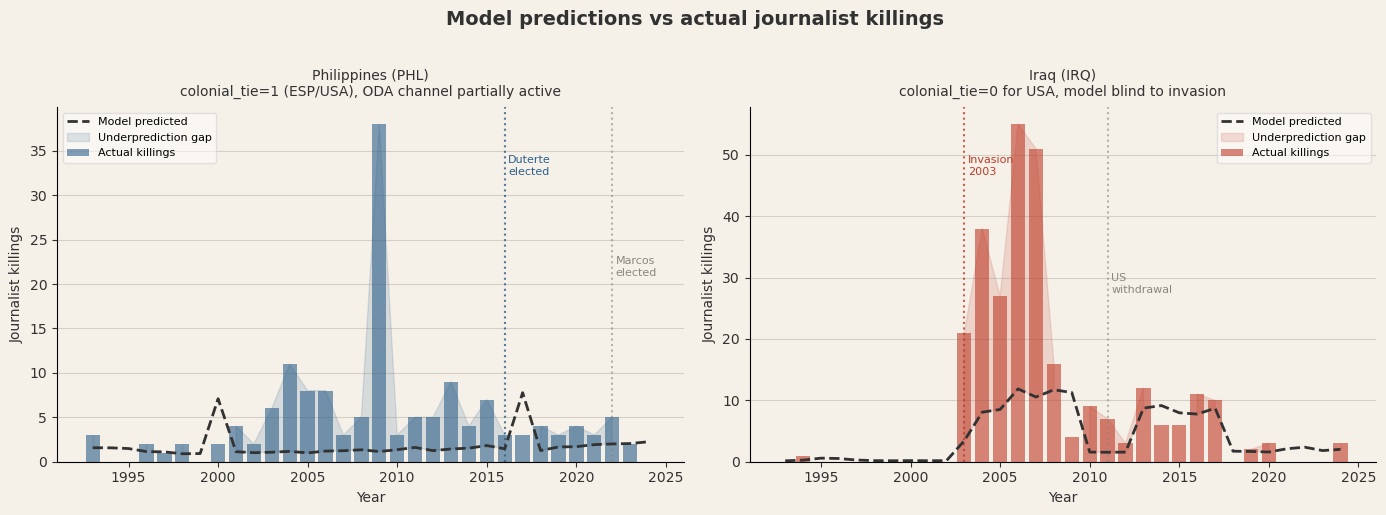

Saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT)
fig.suptitle('Model predictions vs actual journalist killings',
             fontsize=14, color=DARK, fontweight='bold', y=1.02)

cases = [
    (axes[0], phl, 'Philippines (PHL)', PHL_COLOR,
     'colonial_tie=1 (ESP/USA), ODA channel partially active'),
    (axes[1], irq, 'Iraq (IRQ)', IRQ_COLOR,
     'colonial_tie=0 for USA, model blind to invasion')
]

for ax, df, title, color, subtitle in cases:
    ax.set_facecolor(LIGHT)
    ax.bar(df['year'], df['journalist_killings'],
           color=color, alpha=0.6, label='Actual killings', zorder=2)
    ax.plot(df['year'], df['pred_count_hurdle'],
            color=DARK, linewidth=2, linestyle='--', label='Model predicted', zorder=3)
    ax.fill_between(df['year'],
                    df['pred_count_hurdle'], df['journalist_killings'],
                    where=df['journalist_killings'] > df['pred_count_hurdle'],
                    alpha=0.15, color=color, label='Underprediction gap')
    ax.set_title(f'{title}\n{subtitle}', fontsize=10, color=DARK, pad=8)
    ax.set_xlabel('Year', color=DARK)
    ax.set_ylabel('Journalist killings', color=DARK)
    ax.tick_params(colors=DARK)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.5)
    ax.grid(axis='y', alpha=0.3, color=GRAY)

# PHL annotations
ymax0 = phl['journalist_killings'].max()
axes[0].axvline(2016, color=PHL_COLOR, linestyle=':', alpha=0.8, linewidth=1.5)
axes[0].text(2016.2, ymax0*0.85, 'Duterte\nelected', fontsize=8, color=PHL_COLOR)
axes[0].axvline(2022, color=GRAY, linestyle=':', alpha=0.6)
axes[0].text(2022.2, ymax0*0.55, 'Marcos\nelected', fontsize=8, color=GRAY)

# IRQ annotations
ymax1 = irq['journalist_killings'].max()
axes[1].axvline(2003, color=IRQ_COLOR, linestyle=':', alpha=0.8, linewidth=1.5)
axes[1].text(2003.2, ymax1*0.85, 'Invasion\n2003', fontsize=8, color=IRQ_COLOR)
axes[1].axvline(2011, color=GRAY, linestyle=':', alpha=0.6)
axes[1].text(2011.2, ymax1*0.5, 'US\nwithdrawal', fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig('../../outputs/case_study/fig_phl_irq_predictions.png',
            dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()
print('Saved.')

## 7. Figure 2 — ODA Channels

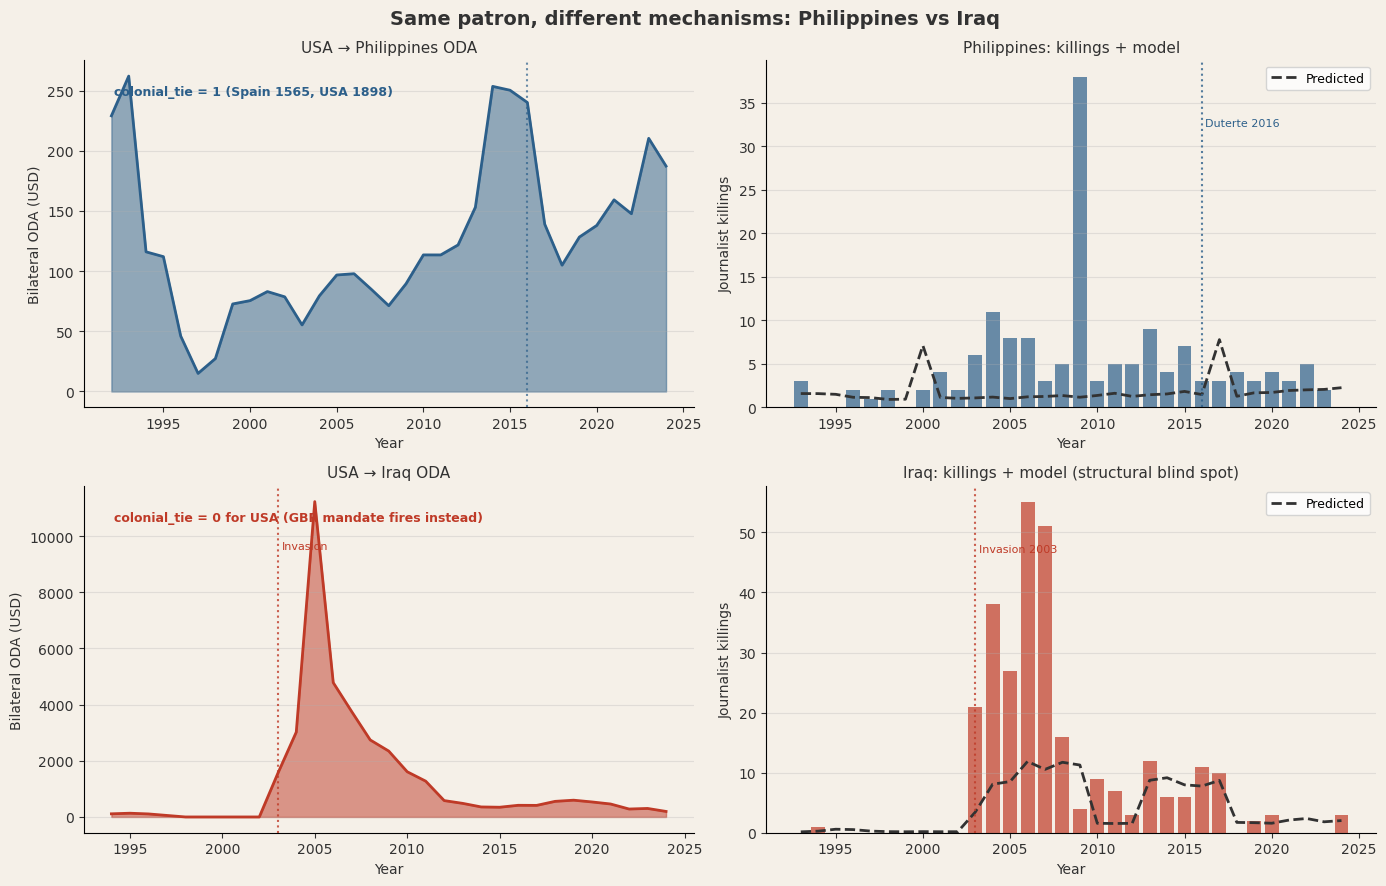

Saved.


In [13]:
usa_phl = dyadic[(dyadic['sender_iso3']=='USA') &
                 (dyadic['recipient_iso3']=='PHL')].sort_values('year')
usa_irq = dyadic[(dyadic['sender_iso3']=='USA') &
                 (dyadic['recipient_iso3']=='IRQ')].sort_values('year')

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=LIGHT)
fig.suptitle('Same patron, different mechanisms: Philippines vs Iraq',
             fontsize=14, color=DARK, fontweight='bold')

# PHL ODA
ax = axes[0,0]
ax.set_facecolor(LIGHT)
if len(usa_phl):
    ax.fill_between(usa_phl['year'], usa_phl['bilateral_oda'], alpha=0.5, color=PHL_COLOR)
    ax.plot(usa_phl['year'], usa_phl['bilateral_oda'], color=PHL_COLOR, linewidth=2)
ax.axvline(2016, color=PHL_COLOR, linestyle=':', alpha=0.7)
ax.set_title('USA → Philippines ODA', color=DARK, fontsize=11)
ax.set_ylabel('Bilateral ODA (USD)', color=DARK)
ax.text(0.05, 0.9, 'colonial_tie = 1 (Spain 1565, USA 1898)',
        transform=ax.transAxes, color=PHL_COLOR, fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

# PHL killings
ax = axes[0,1]
ax.set_facecolor(LIGHT)
ax.bar(phl['year'], phl['journalist_killings'], color=PHL_COLOR, alpha=0.7)
ax.plot(phl['year'], phl['pred_count_hurdle'], color=DARK,
        linewidth=2, linestyle='--', label='Predicted')
ax.axvline(2016, color=PHL_COLOR, linestyle=':', alpha=0.8)
ax.text(2016.2, phl['journalist_killings'].max()*0.85,
        'Duterte 2016', fontsize=8, color=PHL_COLOR)
ax.set_title('Philippines: killings + model', color=DARK, fontsize=11)
ax.set_ylabel('Journalist killings', color=DARK)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

# IRQ ODA
ax = axes[1,0]
ax.set_facecolor(LIGHT)
if len(usa_irq):
    ax.fill_between(usa_irq['year'], usa_irq['bilateral_oda'], alpha=0.5, color=IRQ_COLOR)
    ax.plot(usa_irq['year'], usa_irq['bilateral_oda'], color=IRQ_COLOR, linewidth=2)
ax.axvline(2003, color=IRQ_COLOR, linestyle=':', alpha=0.8)
ax.text(2003.2, usa_irq['bilateral_oda'].max()*0.85 if len(usa_irq) else 1,
        'Invasion', fontsize=8, color=IRQ_COLOR)
ax.set_title('USA → Iraq ODA', color=DARK, fontsize=11)
ax.set_ylabel('Bilateral ODA (USD)', color=DARK)
ax.text(0.05, 0.9, 'colonial_tie = 0 for USA (GBR mandate fires instead)',
        transform=ax.transAxes, color=IRQ_COLOR, fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

# IRQ killings
ax = axes[1,1]
ax.set_facecolor(LIGHT)
ax.bar(irq['year'], irq['journalist_killings'], color=IRQ_COLOR, alpha=0.7)
ax.plot(irq['year'], irq['pred_count_hurdle'], color=DARK,
        linewidth=2, linestyle='--', label='Predicted')
ax.axvline(2003, color=IRQ_COLOR, linestyle=':', alpha=0.8)
ax.text(2003.2, irq['journalist_killings'].max()*0.85,
        'Invasion 2003', fontsize=8, color=IRQ_COLOR)
ax.set_title('Iraq: killings + model (structural blind spot)', color=DARK, fontsize=11)
ax.set_ylabel('Journalist killings', color=DARK)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(axis='y', alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel('Year', color=DARK)

plt.tight_layout()
plt.savefig('../../outputs/case_study/fig_channels_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()
print('Saved.')

## 8. Figure 3 — Scatter All Countries

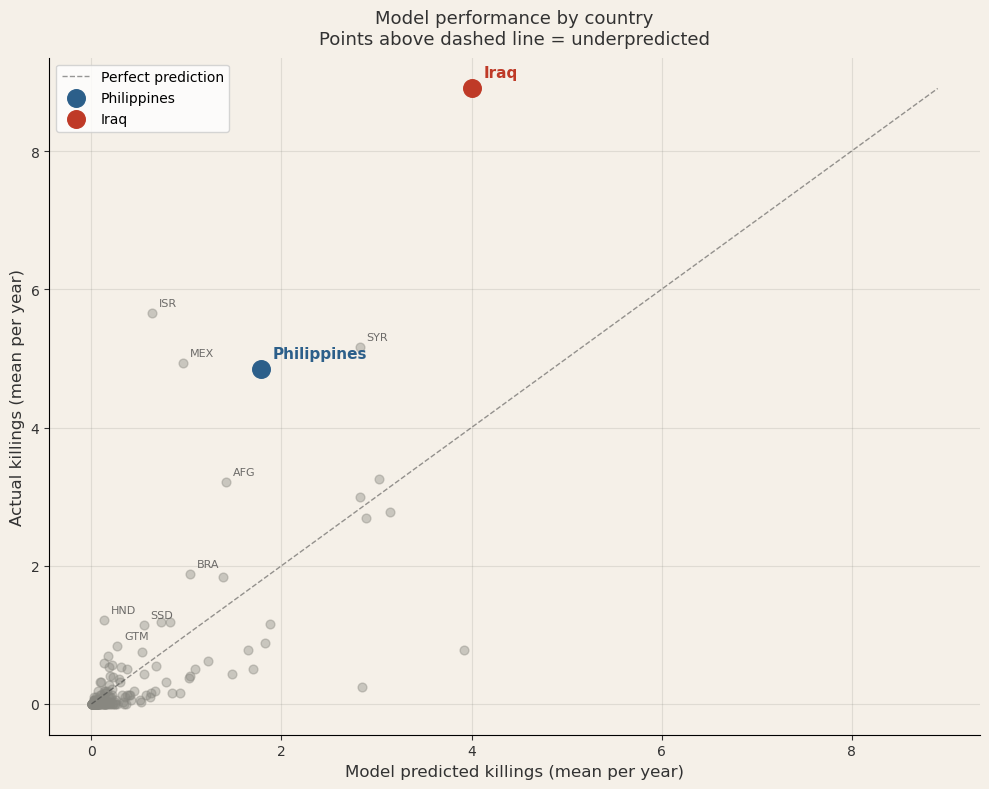

Saved.


In [14]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor=LIGHT)
ax.set_facecolor(LIGHT)

ax.scatter(country_summary['mean_pred'], country_summary['mean_killings'],
           color=GRAY, alpha=0.4, s=40, zorder=2)

maxval = max(country_summary['mean_pred'].max(), country_summary['mean_killings'].max())
ax.plot([0, maxval], [0, maxval], color=DARK, linewidth=1,
        linestyle='--', alpha=0.5, label='Perfect prediction')

for iso, color, label in [('PHL', PHL_COLOR, 'Philippines'), ('IRQ', IRQ_COLOR, 'Iraq')]:
    row = country_summary[country_summary['recipient_iso3']==iso]
    if len(row):
        ax.scatter(row['mean_pred'], row['mean_killings'],
                   color=color, s=160, zorder=5, label=label)
        ax.annotate(label,
                    xy=(row['mean_pred'].values[0], row['mean_killings'].values[0]),
                    xytext=(8, 8), textcoords='offset points',
                    color=color, fontweight='bold', fontsize=11)

top_under = country_summary[
    (country_summary['mean_residual'] > 0.5) &
    (~country_summary['recipient_iso3'].isin(['PHL','IRQ']))
].nlargest(8, 'mean_residual')

for _, row in top_under.iterrows():
    ax.annotate(row['recipient_iso3'],
                xy=(row['mean_pred'], row['mean_killings']),
                xytext=(5, 5), textcoords='offset points',
                color=DARK, fontsize=8, alpha=0.7)

ax.set_xlabel('Model predicted killings (mean per year)', color=DARK, fontsize=12)
ax.set_ylabel('Actual killings (mean per year)', color=DARK, fontsize=12)
ax.set_title('Model performance by country\nPoints above dashed line = underpredicted',
             color=DARK, fontsize=13, pad=10)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=DARK)
ax.grid(alpha=0.2, color=GRAY)

plt.tight_layout()
plt.savefig('../../outputs/case_study/fig_predicted_vs_actual.png',
            dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()
print('Saved.')

## 9. Comparison Table & Summary

In [15]:
vars_check = ['journalist_killings','pred_count_hurdle','residual','p_any_killing',
              TIE_COL, ODA_COL, ARMS_COL, ECON_COL,
              'gdp_per_capita_log','armed_conflict','conflict_intensity']
present_vars = [v for v in vars_check if v and v in model_df.columns]

comp_df = pd.DataFrame({
    'PHL': phl[present_vars].mean().round(3),
    'IRQ': irq[present_vars].mean().round(3)
})
comp_df['IRQ - PHL'] = (comp_df['IRQ'] - comp_df['PHL']).round(3)
print(comp_df.to_string())
comp_df.to_csv('../../outputs/case_study/phl_irq_comparison_table.csv')
print('\nSaved: phl_irq_comparison_table.csv')

                                PHL    IRQ  IRQ - PHL
journalist_killings           4.844  8.906      4.062
pred_count_hurdle             1.785  4.010      2.225
residual                      3.058  4.896      1.838
p_any_killing                 0.529  0.501     -0.028
colonial_tie_flag             1.000  1.000      0.000
oda_total_log_lag1            6.478  6.814      0.336
arms_tiv_total_log_lag1       3.488  3.314     -0.174
econ_neocol_score_total_lag1  5.491  5.771      0.280
gdp_per_capita_log            7.533  7.738      0.205
armed_conflict                1.000  0.812     -0.188
conflict_intensity            1.062  1.188      0.126

Saved: phl_irq_comparison_table.csv


In [16]:
# Copy everything to final report folder
for f in os.listdir('../../outputs/case_study/'):
    shutil.copy2(f'../../outputs/case_study/{f}', f'../../outputs/final_report/06_case_study/{f}')
    print(f'Copied: {f}')

Copied: fig_phl_irq_predictions.png
Copied: country_residuals.csv
Copied: phl_irq_comparison_table.csv
Copied: fig_predicted_vs_actual.png
Copied: fig_channels_comparison.png


In [17]:
print('='*65)
print('CASE STUDY DIAGNOSTIC SUMMARY — Philippines vs Iraq')
print('='*65)
for iso, name in [('PHL','PHILIPPINES'), ('IRQ','IRAQ')]:
    r = country_summary[country_summary['recipient_iso3']==iso]
    if not len(r): print(f'{name}: not found'); continue
    r = r.iloc[0]
    df_iso = model_df[model_df['recipient_iso3']==iso]
    peak = df_iso.loc[df_iso['journalist_killings'].idxmax(),'year']
    print(f'\n{name} ({iso})')
    print(f'  Total killings:       {r["total_killings"]:.0f}')
    print(f'  Total predicted:      {r["total_pred"]:.1f}')
    print(f'  Mean annual residual: {r["mean_residual"]:.3f}')
    print(f'  Mean P(any killing):  {r["mean_p_any"]:.3f}')
    print(f'  Colonial tie:         {r["colonial_tie"]:.0f}')
    print(f'  Peak killing year:    {peak}')
    print(f'  Peak killings:        {df_iso["journalist_killings"].max():.0f}')
print('\n' + '='*65)
print('KEY FINDING')
print('  PHL: colonial_tie=1 (Spain/USA), ODA channel active, model partially works')
print('  IRQ: colonial_tie=0 for USA, invasion invisible, model catastrophically fails')
print('  Same patron (US), two mechanisms — one legible, one not')
print('  THIS GAP IS THE BIAS AUDIT')
print('='*65)

CASE STUDY DIAGNOSTIC SUMMARY — Philippines vs Iraq

PHILIPPINES (PHL)
  Total killings:       155
  Total predicted:      57.1
  Mean annual residual: 3.058
  Mean P(any killing):  0.529
  Colonial tie:         1
  Peak killing year:    2009
  Peak killings:        38

IRAQ (IRQ)
  Total killings:       285
  Total predicted:      128.3
  Mean annual residual: 4.896
  Mean P(any killing):  0.501
  Colonial tie:         1
  Peak killing year:    2006
  Peak killings:        55

KEY FINDING
  PHL: colonial_tie=1 (Spain/USA), ODA channel active, model partially works
  IRQ: colonial_tie=0 for USA, invasion invisible, model catastrophically fails
  Same patron (US), two mechanisms — one legible, one not
  THIS GAP IS THE BIAS AUDIT
